In [1]:
!pip install python-docx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.4 MB/s eta 0:00:00


In [2]:
import pandas as pd

df = pd.read_csv("calif.csv", encoding='latin1')

materias = df.iloc[1, 1:].tolist()

alumnos = df.iloc[2:].reset_index(drop=True)
alumnos.columns = ['Nombre'] + materias
alumnos = alumnos.dropna(subset=['Nombre']).reset_index(drop=True)

for m in materias:
    alumnos[m] = pd.to_numeric(alumnos[m], errors='coerce')

alumnos['Promedio'] = alumnos[materias].mean(axis=1).round(2)

print(alumnos[['Nombre', 'Promedio']])

                         Nombre  Promedio
0         Arturo Perez Pasillas       6.4
1        Marisol Domínguez Maya       5.6
2       Arturo Coronado Mendoza       5.4
3            David Pineda Ramos       7.2
4      Miguelito FreeFire Ramos      10.0
5      Alberto Camacho Espinoza      10.0
6  Eduardo Alberto Lazo Blanca        8.4
7       Michael Cascada Tostada       9.2
8          Adam Rafael Pasillas      10.0
9             Gabe Logan Newell       9.8


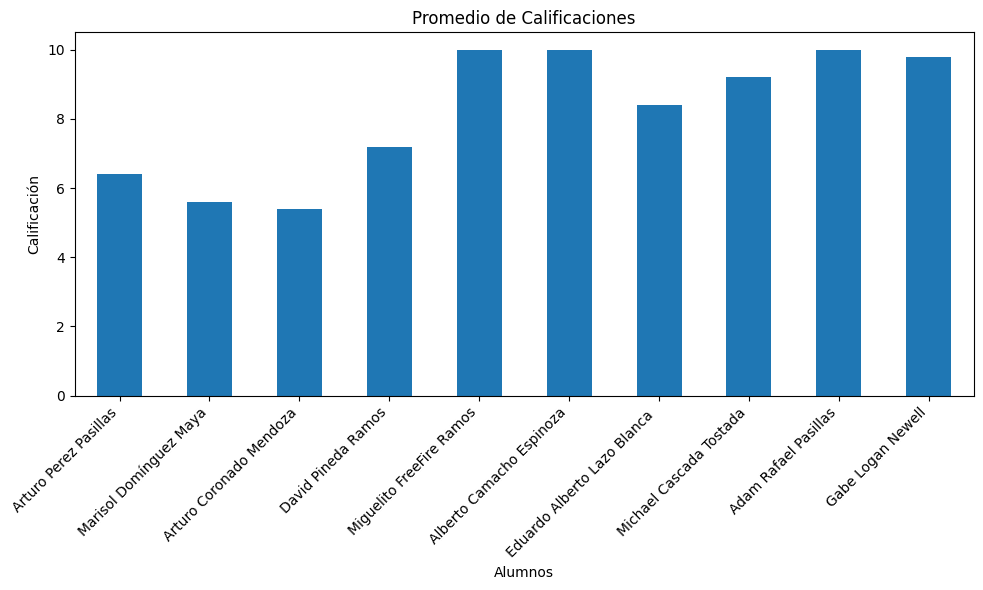

In [33]:
import matplotlib.pyplot as plt

data = alumnos[['Nombre', 'Promedio']]

alumnos.plot(kind='bar', x='Nombre', y='Promedio', legend=False, figsize=(10, 6))

plt.title('Promedio de Calificaciones')
plt.ylabel('Calificación')
plt.xlabel('Alumnos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
from docx import Document
from docx.shared import Pt, Inches, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH, WD_LINE_SPACING
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from datetime import date
import os, zipfile


ESCUELA = 'Escuela Primaria "Benito Juárez"'
CICLO = '2025 – 2026'
GRADO = '3° Grado, Grupo A'
CIUDAD = 'Tepic, Nayarit'
DOCENTE = 'Profa. María Martínez Soto'
DIRECTOR = 'Prof. Juan García López'


hoy = date.today()
meses = {
    'January': 'enero', 'February': 'febrero', 'March': 'marzo', 'April': 'abril',
    'May': 'mayo', 'June': 'junio', 'July': 'julio', 'August': 'agosto',
    'September': 'septiembre', 'October': 'octubre', 'November': 'noviembre', 'December': 'diciembre'
}
en = hoy.strftime("%B")
es = meses[en]
fecha = f'{hoy.day} de {es} de {hoy.year}'

def aplicar_sombreado_celda(celda, color):
    """Aplica un color de fondo (en hex, ej: '2C3E50') a una celda."""
    tc = celda._tc
    tcPr = tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:fill'), color)
    tcPr.append(shd)

def aplicar_sombreado_parrafo(parrafo, color):
    """Aplica un color de fondo a un párrafo."""
    p_elm = parrafo._element
    pPr = p_elm.get_or_add_pPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:fill'), color)
    pPr.append(shd)

def crear_carta(nombre, calificaciones, promedio):
    doc = Document()


    section = doc.sections[0]
    section.top_margin = Cm(1.5)
    section.bottom_margin = Cm(1.5)
    section.left_margin = Cm(2.5)
    section.right_margin = Cm(2.5)


    p = doc.add_paragraph(ESCUELA)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.runs[0].bold = True
    p.runs[0].font.size = Pt(14)
    doc.add_paragraph(f'Ciclo Escolar {CICLO}').alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph(GRADO).alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph('')


    p = doc.add_paragraph(f'{CIUDAD}, a {fecha}.')
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    doc.add_paragraph('')


    p = doc.add_paragraph('Estimado Padre / Madre de Familia o Tutor(a):')
    p.runs[0].bold = True
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)

    p = doc.add_paragraph(f'Del alumno(a): {nombre}')
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    doc.add_paragraph('')


    p = doc.add_paragraph(f'Por medio de la presente, reciba un cordial saludo de parte del personal docente de {ESCUELA}.')
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    p.runs[0].font.size = Pt(11)

    p = doc.add_paragraph(
        f'Nos dirigimos a usted para hacer entrega del Primer Reporte de Calificaciones '
        f'del ciclo escolar {CICLO}, correspondiente a su hijo(a) {nombre}, perteneciente a {GRADO}.'
    )
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    p.runs[0].font.size = Pt(11)

    p = doc.add_paragraph('A continuación se presentan las calificaciones obtenidas:')
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    p.runs[0].font.size = Pt(11)


    tabla = doc.add_table(rows=1, cols=2)
    tabla.style = 'Table Grid'


    celda_asig = tabla.rows[0].cells[0]
    celda_calif = tabla.rows[0].cells[1]
    celda_asig.text = 'Asignatura'
    celda_calif.text = 'Calificación'

    aplicar_sombreado_celda(celda_asig, '2C3E50')
    aplicar_sombreado_celda(celda_calif, '2C3E50')

    for run in celda_asig.paragraphs[0].runs:
        run.font.color.rgb = RGBColor(255, 255, 255)
        run.bold = True
        run.font.size = Pt(11)
    for run in celda_calif.paragraphs[0].runs:
        run.font.color.rgb = RGBColor(255, 255, 255)
        run.bold = True
        run.font.size = Pt(11)


    for materia, calif in calificaciones.items():
        fila = tabla.add_row().cells
        fila[0].text = materia
        fila[1].text = str(int(calif))
        for celda in fila:
            for p in celda.paragraphs:
                p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
                p.paragraph_format.space_after = Pt(0)
                if p.runs:
                    p.runs[0].font.size = Pt(11)


    fila_prom = tabla.add_row().cells
    fila_prom[0].text = 'PROMEDIO GENERAL'
    fila_prom[1].text = str(promedio)
    fila_prom[0].paragraphs[0].runs[0].bold = True
    fila_prom[1].paragraphs[0].runs[0].bold = True
    for celda in fila_prom:
        for p in celda.paragraphs:
            p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
            p.paragraph_format.space_after = Pt(0)
            if p.runs:
                p.runs[0].font.size = Pt(11)

    doc.add_paragraph('')


    if promedio < 6:
        p = doc.add_paragraph('RECOMENDACIÓN ESPECIAL:')
        p.runs[0].bold = True
        p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
        p.paragraph_format.first_line_indent = Cm(0.63)
        p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
        p.paragraph_format.space_after = Pt(0)
        aplicar_sombreado_parrafo(p, 'F2F2F2')

        p = doc.add_paragraph(
            f'El promedio de {nombre} ({promedio}) está por debajo del mínimo aprobatorio (6.0). Le recomendamos:'
        )
        p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
        p.paragraph_format.first_line_indent = Cm(0.63)
        p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
        p.paragraph_format.space_after = Pt(0)
        p.runs[0].font.size = Pt(11)

        for recomendacion in [
            '• Establecer un horario fijo de estudio en casa.',
            '• Revisar diariamente las tareas y actividades escolares.',
            '• Solicitar asesorías adicionales con el docente.',
            '• Asistir a la próxima reunión de padres de familia.'
        ]:
            p = doc.add_paragraph(recomendacion)
            p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
            p.paragraph_format.first_line_indent = Cm(0.63)
            p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
            p.paragraph_format.space_after = Pt(0)
            p.runs[0].font.size = Pt(11)
    else:
        p = doc.add_paragraph('Le invitamos a seguir motivando a su hijo(a) para mantener o superar este desempeño.')
        p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
        p.paragraph_format.first_line_indent = Cm(0.63)
        p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
        p.paragraph_format.space_after = Pt(0)
        p.runs[0].font.size = Pt(11)

    doc.add_paragraph('')

    p = doc.add_paragraph('Agradecemos su atención y colaboración. Quedamos a sus órdenes para cualquier duda.')
    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.first_line_indent = Cm(0.63)
    p.paragraph_format.line_spacing_rule = WD_LINE_SPACING.SINGLE
    p.paragraph_format.space_after = Pt(0)
    p.runs[0].font.size = Pt(11)
    doc.add_paragraph('')
    doc.add_paragraph('Atentamente,')
    doc.add_paragraph('')
    doc.add_paragraph('')


    p = doc.add_paragraph(DOCENTE)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.runs[0].bold = True
    doc.add_paragraph(f'Docente — {GRADO}').alignment = WD_ALIGN_PARAGRAPH.CENTER
    doc.add_paragraph('')
    p = doc.add_paragraph(DIRECTOR)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    p.runs[0].bold = True
    doc.add_paragraph('Director(a)').alignment = WD_ALIGN_PARAGRAPH.CENTER

    return doc


if not os.path.exists('cartas'):
    os.makedirs('cartas')

for index, alumno_data in alumnos.iterrows():
    nombre = alumno_data['Nombre']
    califs = {materia: alumno_data[materia] for materia in materias}
    promedio = alumno_data['Promedio']

    doc = crear_carta(nombre, califs, promedio)
    nombre_archivo_limpio = nombre.replace(" ", "_").replace("ñ", "n").replace("Ñ", "N").replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u").replace("Á", "A").replace("É", "E").replace("Í", "I").replace("Ó", "O").replace("Ú", "U")
    nombre_archivo = f'cartas/{nombre_archivo_limpio}.docx'
    doc.save(nombre_archivo)

In [50]:
from google.colab import files

with zipfile.ZipFile('cartas.zip', 'w') as zf:
    for archivo in os.listdir('cartas'):
        zf.write(f'cartas/{archivo}', archivo)

files.download('cartas.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>